# Homework 1: Gradient Descent

```{warning}
The submission of the homeworks has **NO** deadline. You can submit them whenever you want, on Virtuale. You are only required to upload it on Virtuale **BEFORE** your exam session, since the Homeworks will be a central part of the oral exam. 

You are asked to submit the homework as one of the two, following modalities:
* A PDF (or Word) document, containing screenshoots of code snippets, screeshots of the results generated by your code, and a brief comment on the obtained results.
* A Python Notebook (i.e. a `.ipynb` file), with cells containing the code required to solve the indicated exercises, alternated with a brief comment on the obtained results in the form of a markdown cell. We remark that the code **SHOULD NOT** be runned during the exam, but the student is asked to enter the exam with all the programs **already executed**, with the results clearly visible on the screen.

Joining the oral exam with a non-executed code OR without a PDF file with the obtained results visible on that, will cause the student to be rejected.
```

## Exercise 1: GD on a 1D Function

Consider the 1-dimensional function

$$
\mathcal{L}(\Theta)  = (\Theta - 3)^2 + 1.
$$


1. **Compute the Gradient** of $\mathcal{L}(\Theta)$ explicitly.

2. **Implement the Gradient Descent** to optimize $\mathcal{L}(\Theta)$ following what we introduced on the theoretical sections.

3. Test three different constant step sizes:
   - $\eta = 0.05$  
   - $\eta = 0.2$
   - $\eta = 1.0$

4. For each choice:
   - Plot the sequence $\Theta^{(k)}$ on the real line (i.e. draw a line and represent, on top of it, the position of all the successive elements $\Theta^{(k)}$).  
   - Plot the function values $\mathcal{L}(\Theta^{(k)})$ vs iteration.  
   - Comment on convergence, oscillations, and divergence.

5. Relate your observations to the discussion in class about:
   - step-size being too small / too large,
   - the role of convexity,
   - how the “just right” step size leads to fast convergence.

*Hint:* This function is strictly convex with a unique minimizer at $\Theta^* = 3$.


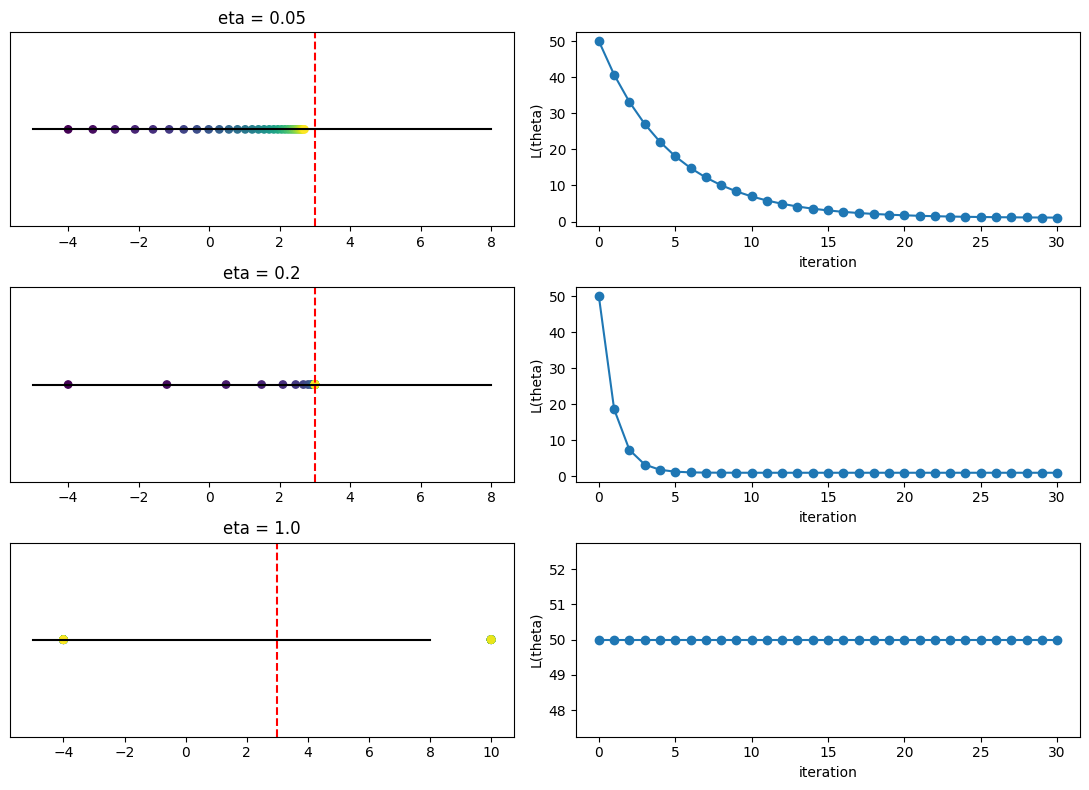

0.05 2.7032618920734865 1.088053504695807
0.2 2.9999984524825623 1.0000000000023948
1.0 -4.0 50.0


In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

def L(theta):
    return (theta - 3)**2 + 1

def grad_L(theta):
    return 2*(theta - 3)

def gradient_descent_1d(L, grad_L, theta0, eta, epochs=40):
    theta = float(theta0)
    thetas = [theta]
    losses = [L(theta)]
    for k in range(epochs):
        theta = theta - eta*grad_L(theta)
        thetas.append(theta)
        losses.append(L(theta))
    return np.array(thetas), np.array(losses)

etas = [0.05, 0.2, 1.0]
runs = {}
for eta in etas:
    runs[eta] = gradient_descent_1d(L, grad_L, theta0=-4, eta=eta, epochs=30)

xx = np.linspace(-5, 8, 400)
fig, axes = plt.subplots(len(etas), 2, figsize=(11, 8))
for i, eta in enumerate(etas):
    thetas, losses = runs[eta]
    axes[i, 0].plot(xx, np.zeros_like(xx), color="black")
    axes[i, 0].scatter(thetas, np.zeros_like(thetas), c=np.arange(len(thetas)), cmap="viridis", s=28)
    axes[i, 0].axvline(3, color="red", linestyle="--")
    axes[i, 0].set_yticks([])
    axes[i, 0].set_title(f"eta = {eta}")
    axes[i, 1].plot(losses, "o-")
    axes[i, 1].set_xlabel("iteration")
    axes[i, 1].set_ylabel("L(theta)")
plt.tight_layout()
plt.show()

for eta in etas:
    thetas, losses = runs[eta]
    print(eta, thetas[-1], losses[-1])


## Exercise 2: Backtracking Line Search

Consider the non-convex function

$$
\mathcal{L}(\Theta)  = \Theta^4 - 3\Theta^2 + 2.
$$


1. Implement **Gradient Descent with Backtracking**, using the Armijo condition, considering the `backtracking(...)` function from class.
   
2. Test different initial points:
   - $\Theta_0 = -2$
   - $\Theta_0 = 0.5$
   - $\Theta_0 = 2$

3. For each starting point, plot:
   - the function curve $\mathcal{L}(\Theta)$ in 1D in the domain $[-3, 3]$,
   - the trajectory of the iterates $\Theta^{(k)}$ overlaid on the curve.

4. Discuss:
   - Why different initializations converge to different minima.  
   - How backtracking automatically chooses a suitable step size at each iteration.  
   - Situations where constant step size would fail.


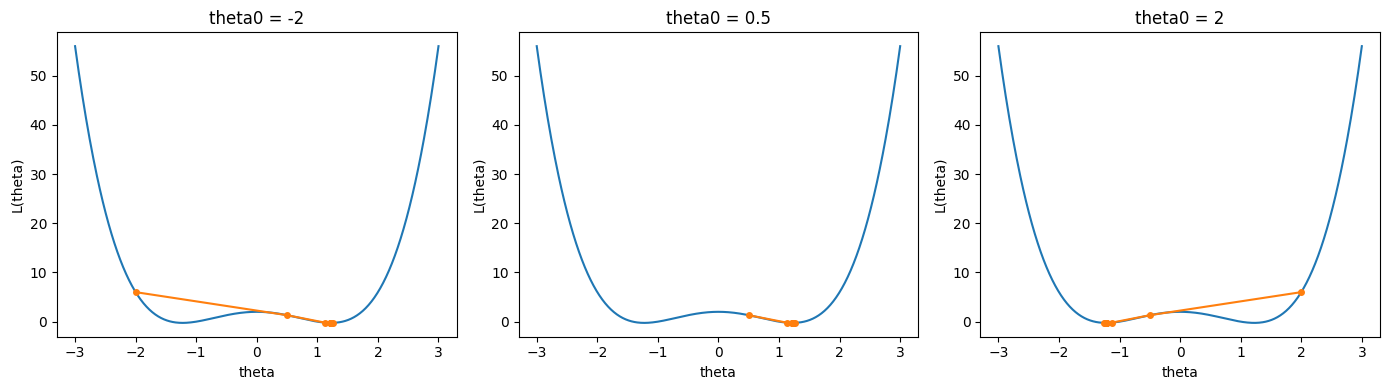

-2 1.2247448717102325 -0.25000000000000044 31 [0.125 0.25  0.125 0.125 0.125]
0.5 1.2247448717102325 -0.25000000000000044 30 [0.25  0.125 0.125 0.125 0.125]
2 -1.2247448717102325 -0.25000000000000044 31 [0.125 0.25  0.125 0.125 0.125]


In [2]:
import numpy as np
import matplotlib.pyplot as plt


def L(theta):
    return theta**4 - 3*theta**2 + 2

def grad_L(theta):
    return 4*theta**3 - 6*theta

def backtracking(L, grad_L, theta, eta0=1.0, beta=0.5, c=1e-4):
    eta = eta0
    g = grad_L(theta)
    while L(theta - eta*g) > L(theta) - c*eta*g**2:
        eta = beta*eta
    return eta

def gd_backtracking_1d(L, grad_L, theta0, tol=1e-8, epochs=100):
    theta = float(theta0)
    thetas = [theta]
    etas = []
    losses = [L(theta)]
    for k in range(epochs):
        g = grad_L(theta)
        if abs(g) < tol:
            break
        eta = backtracking(L, grad_L, theta)
        theta = theta - eta*g
        thetas.append(theta)
        losses.append(L(theta))
        etas.append(eta)
    return np.array(thetas), np.array(losses), np.array(etas)

starts = [-2, 0.5, 2]
xx = np.linspace(-3, 3, 500)
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, theta0 in zip(axes, starts):
    thetas, losses, etas = gd_backtracking_1d(L, grad_L, theta0)
    ax.plot(xx, L(xx))
    ax.plot(thetas, L(thetas), "o-", markersize=4)
    ax.set_title(f"theta0 = {theta0}")
    ax.set_xlabel("theta")
    ax.set_ylabel("L(theta)")
plt.tight_layout()
plt.show()

for theta0 in starts:
    thetas, losses, etas = gd_backtracking_1d(L, grad_L, theta0)
    print(theta0, thetas[-1], losses[-1], len(thetas)-1, etas[:5])


## Exercise 3: GD in 2D

Consider the quadratic function:

$$
\mathcal{L}(\Theta) = \tfrac{1}{2}\,\Theta^T A\,\Theta,
\qquad
A = \begin{bmatrix}1 & 0 \\ 0 & 25\end{bmatrix}.
$$


1. Implement Gradient Descent in 2D, as seen in class.
   

2. Plot the **level sets** of $L$ (using the helper code provided in the lecture notes) and overlay the iterates $\Theta^{(k)}$ for:
   - $\eta = 0.02$,
   - $\eta = 0.05$ (borderline),
   - $\eta = 0.1$ (diverging).
   To overlay the iterates on the plot, simply add a `plt.plot(...)` function taking as input the coordinates $\Theta_1^{(k)}$ and $\Theta_2^{(k)}$ for each $k$.

3. Comment on:
   - the elongated ellipses produced by ill-conditioning,
   - the gradient direction compared to the level set lines,
   - zig-zag behaviour for large condition numbers,
   - the relation to the lecture discussion on slow convergence in narrow valleys.


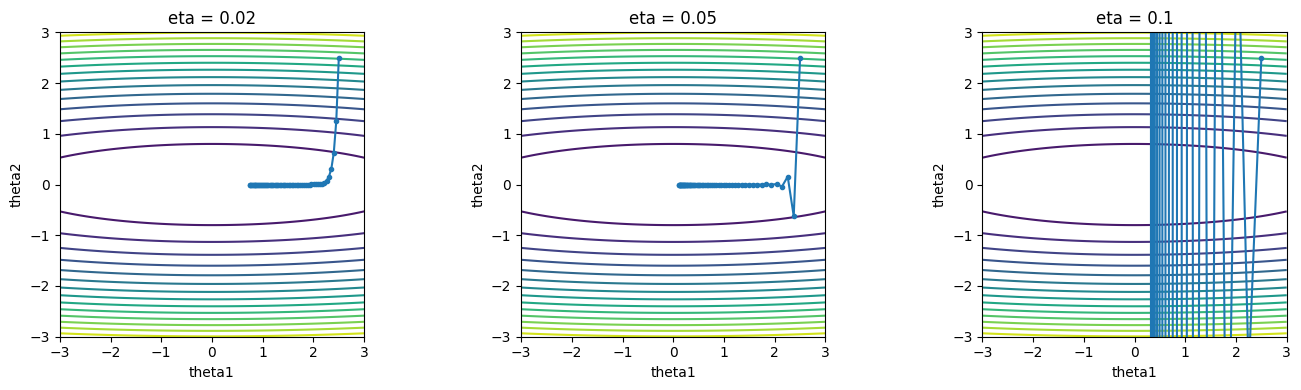

0.02 [7.43882857e-01 2.16840434e-18] 0.27668085226861766
0.05 [1.15174497e-01 1.88079096e-36] 0.006632582433431786
0.1 [3.03941636e-01 8.31314183e+03] 863854087.6196287


In [3]:
import numpy as np
import matplotlib.pyplot as plt

A = np.array([[1, 0], [0, 25]], dtype=float)

def L(theta):
    return 0.5*theta.T @ A @ theta

def grad_L(theta):
    return A @ theta

def gradient_descent_2d(L, grad_L, theta0, eta, epochs=60):
    theta = theta0.astype(float).copy()
    thetas = [theta.copy()]
    losses = [L(theta)]
    for k in range(epochs):
        theta = theta - eta*grad_L(theta)
        thetas.append(theta.copy())
        losses.append(L(theta))
    return np.array(thetas), np.array(losses)

def quad_levelsets(A, xlim=(-3, 3), ylim=(-3, 3), ngrid=400, ncontours=18, ax=None):
    if ax is None:
        ax = plt.gca()
    xs = np.linspace(xlim[0], xlim[1], ngrid)
    ys = np.linspace(ylim[0], ylim[1], ngrid)
    X, Y = np.meshgrid(xs, ys)
    Z = 0.5*(A[0,0]*X**2 + 2*A[0,1]*X*Y + A[1,1]*Y**2)
    ax.contour(X, Y, Z, levels=ncontours)
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_aspect("equal")
    return ax

etas = [0.02, 0.05, 0.1]
theta0 = np.array([2.5, 2.5])
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, eta in zip(axes, etas):
    epochs = 20 if eta == 0.1 else 60
    thetas, losses = gradient_descent_2d(L, grad_L, theta0, eta, epochs=epochs)
    quad_levelsets(A, ax=ax)
    ax.plot(thetas[:, 0], thetas[:, 1], "o-", markersize=3)
    ax.set_title(f"eta = {eta}")
    ax.set_xlabel("theta1")
    ax.set_ylabel("theta2")
plt.tight_layout()
plt.show()

for eta in etas:
    epochs = 20 if eta == 0.1 else 60
    thetas, losses = gradient_descent_2d(L, grad_L, theta0, eta, epochs=epochs)
    print(eta, thetas[-1], losses[-1])


## Exercise 4: Exact Line Search vs Backtracking

Let

$$
\mathcal{L}(\Theta) = \frac{1}{2}\Theta^T A \Theta,\qquad
A=\begin{bmatrix}5 & 0\\0 & 2\end{bmatrix}.
$$


1. For GD with **exact line search** i.e. selecting the **optimal** step, you get:
   
   $$
   \eta_k^* = \frac{g_k^T g_k}{g_k^T A\,g_k},
   \qquad g_k = A\,\Theta^{(k)}.
   $$
   

2. For GD with **backtracking**, use the implementation provided in your notes.

3. Starting from $\Theta_0 = (3,\,3)^T$:
   - Plot trajectories on the level-set map.  
   - Plot the loss $\mathcal{L}(\Theta^{(k)})$ vs iteration for both methods.  

4. Compare:
   - speed of convergence,
   - smoothness of step-sizes.


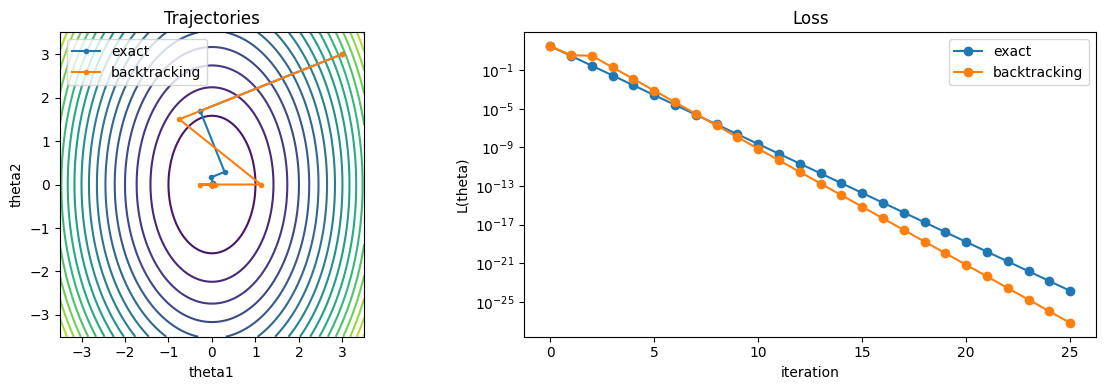

exact 1.350925082426929e-24 [0.21804511 0.41428571 0.21804511 0.41428571 0.21804511 0.41428571
 0.21804511 0.41428571]
backtracking 6.389773332290196e-28 [0.25 0.5  0.25 0.25 0.25 0.25 0.25 0.25]


In [4]:
import numpy as np
import matplotlib.pyplot as plt

A = np.array([[5, 0], [0, 2]], dtype=float)

def L(theta):
    return 0.5*theta.T @ A @ theta

def grad_L(theta):
    return A @ theta

def backtracking(L, grad_L, theta, eta0=1.0, beta=0.5, c=1e-4):
    eta = eta0
    g = grad_L(theta)
    while L(theta - eta*g) > L(theta) - c*eta*np.linalg.norm(g)**2:
        eta = beta*eta
    return eta

def gd_exact(theta0, epochs=25):
    theta = theta0.astype(float).copy()
    thetas = [theta.copy()]
    losses = [L(theta)]
    etas = []
    for k in range(epochs):
        g = grad_L(theta)
        eta = (g.T @ g)/(g.T @ A @ g)
        theta = theta - eta*g
        thetas.append(theta.copy())
        losses.append(L(theta))
        etas.append(eta)
    return np.array(thetas), np.array(losses), np.array(etas)

def gd_backtracking(theta0, epochs=25):
    theta = theta0.astype(float).copy()
    thetas = [theta.copy()]
    losses = [L(theta)]
    etas = []
    for k in range(epochs):
        g = grad_L(theta)
        eta = backtracking(L, grad_L, theta)
        theta = theta - eta*g
        thetas.append(theta.copy())
        losses.append(L(theta))
        etas.append(eta)
    return np.array(thetas), np.array(losses), np.array(etas)

def quad_levelsets(A, xlim=(-3.5, 3.5), ylim=(-3.5, 3.5), ax=None):
    if ax is None:
        ax = plt.gca()
    xs = np.linspace(xlim[0], xlim[1], 400)
    ys = np.linspace(ylim[0], ylim[1], 400)
    X, Y = np.meshgrid(xs, ys)
    Z = 0.5*(A[0,0]*X**2 + A[1,1]*Y**2)
    ax.contour(X, Y, Z, levels=18)
    ax.set_aspect("equal")
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

theta0 = np.array([3, 3], dtype=float)
exact_t, exact_l, exact_e = gd_exact(theta0)
bt_t, bt_l, bt_e = gd_backtracking(theta0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
quad_levelsets(A, ax=axes[0])
axes[0].plot(exact_t[:,0], exact_t[:,1], "o-", label="exact", markersize=3)
axes[0].plot(bt_t[:,0], bt_t[:,1], "o-", label="backtracking", markersize=3)
axes[0].legend()
axes[0].set_xlabel("theta1")
axes[0].set_ylabel("theta2")
axes[0].set_title("Trajectories")
axes[1].semilogy(exact_l, "o-", label="exact")
axes[1].semilogy(bt_l, "o-", label="backtracking")
axes[1].set_xlabel("iteration")
axes[1].set_ylabel("L(theta)")
axes[1].set_title("Loss")
axes[1].legend()
plt.tight_layout()
plt.show()

print("exact", exact_l[-1], exact_e[:8])
print("backtracking", bt_l[-1], bt_e[:8])


## Exercise 5: Gradient Descent on the Rosenbrock Function

The 2-dimensional Rosenbrock function is defined as:

$$
\mathcal(\Theta) = (1 - \Theta_1)^2 + 100(\Theta_2 - \Theta_1^2)^2,
$$

with a unique global minimum at:

$$
\Theta^* = (1,\,1), \qquad \mathcal{L}(\Theta_1^*,\Theta_2y^*) = 0.
$$


Despite having only one minimum, its landscape is **extremely challenging**:
- The valley is long and curved.
- The condition number varies drastically across the region.
- Gradients can point almost orthogonally to the valley direction.
- Gradient Descent may zig-zag and make very slow progress toward the solution.

This makes Rosenbrock a perfect testbed to study the difficulties of pure Gradient Descent.

1. Implement the function and its gradient to run the Gradient Descent algorithm. Test its performance using both **constant step size** and the **backtracking algorithm**.

2. Plot the level sets of $\mathcal{L}$: use the standard 2D contour plotting approach practiced earlier.  
Ensure that you plot:

- A wide range (e.g. $\Theta_1 \in[-2,2]$, $\Theta_2 \in[-1,3]$)
- A reasonable number of contour lines to visualize the narrow valley.

1. Choose multiple initial points, testing at least the following four:
- $\Theta^{(0)} = (-1.5, \; 2)$
- $\Theta^{(0)} = (-1, \; 0)$
- $\Theta^{(0)} = (0, \; 2)$
- $\Theta^{(0)} = (1.5, \; 1.5)$

Run both:
- GD with constant step size (try $\eta = 10^{-3}$, $10^{-4}$, $10^{-5}$),
- GD with backtracking line search.

2. Visualize and analyze the trajectories: For each initialization and each training method:

   1. Plot the sequence of iterates $(\Theta_1^{(k)}, \Theta_2^{(k)})$ as a path on the level-set map.
   2. Plot the loss curve $L(\Theta^{(k)})$ vs iteration.
   3. Observe and explain:
      - whether the method enters the valley,
      - how long it takes to “turn” correctly along the valley direction,
      - whether the method zig-zags,
      - whether step sizes become too small (with constant $\eta$) or too large (divergence).


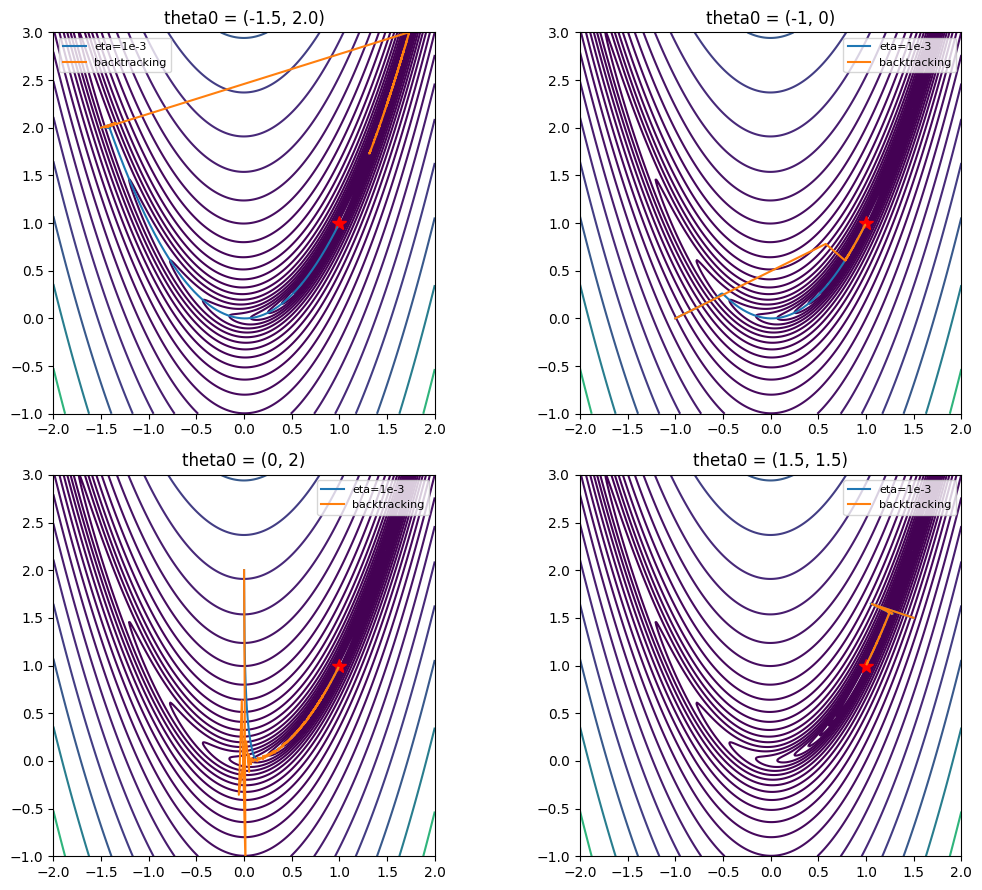

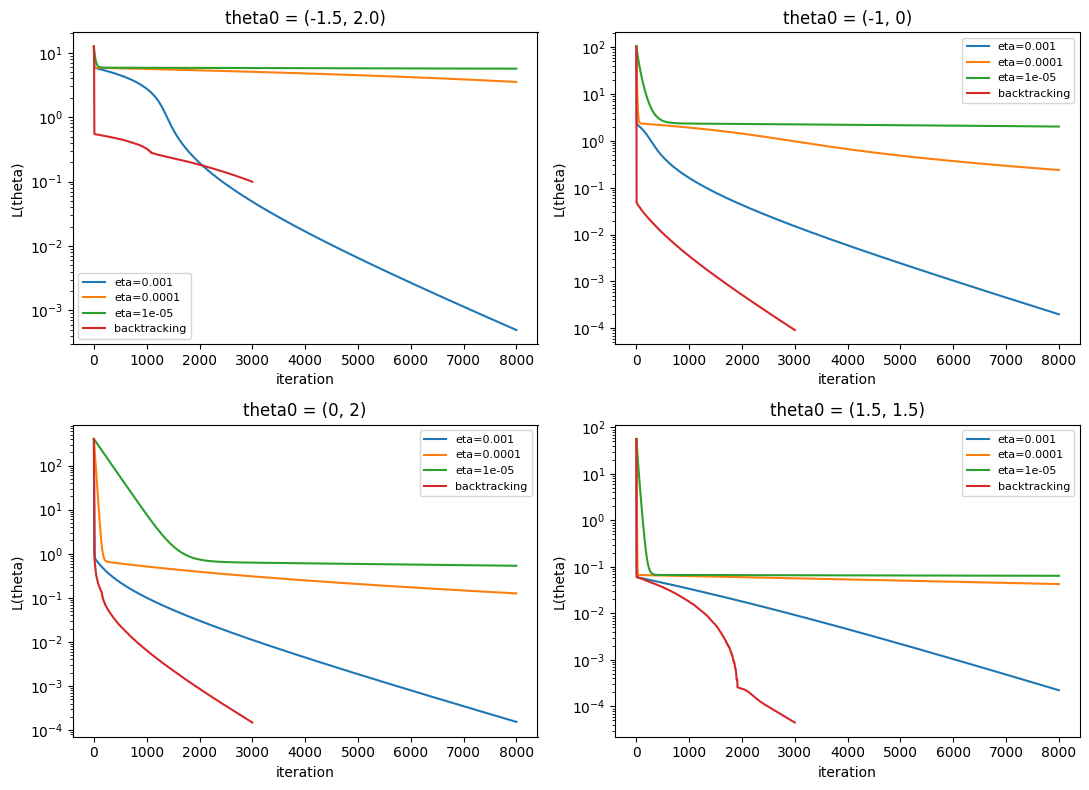

theta0 [-1.5  2. ]
constant 0.001 [0.97778574 0.95597486] 0.0004942850276824906 8000
constant 0.0001 [-0.87535867  0.77432904] 3.523492708043558 8000
constant 1e-05 [-1.37759965  1.9054055 ] 5.658793715191987 8000
backtracking [1.31463614 1.72989276] 0.09925982608426683 3000 [0.00097656 0.00097656 0.00097656 0.00097656 0.0625    ]
theta0 [-1  0]
constant 0.001 [0.98591584 0.97197321] 0.00019868657936371992 8000
constant 0.0001 [0.51080426 0.25846953] 0.2399134412817532 8000
constant 1e-05 [-0.42312361  0.18608664] 2.0302553488823913 8000


backtracking [0.99047993 0.98095478] 9.15478808269197e-05 3000 [0.00390625 0.00195312 0.00195312 0.00195312 0.0078125 ]
theta0 [0 2]
constant 0.001 [0.98763551 0.97537405] 0.00015312907850462183 8000
constant 0.0001 [0.64564993 0.41514568] 0.12585917571649557 8000
constant 1e-05 [0.27024884 0.069992  ] 0.5334623962626063 8000
backtracking [0.98783781 0.97583979] 0.0001479451658585053 3000 [0.0078125 0.0078125 0.0078125 0.0078125 0.0078125]
theta0 [1.5 1.5]
constant 0.001 [1.01492075 1.0301233 ] 0.0002229788542458395 8000
constant 0.0001 [1.20684064 1.45719589] 0.04283656791600265 8000
constant 1e-05 [1.25389213 1.57311913] 0.06453754097405222 8000


backtracking [1.00670707 1.01346287] 4.498621077527993e-05 3000 [0.00097656 0.00097656 0.00097656 0.00097656 0.00097656]


In [5]:
import numpy as np
import matplotlib.pyplot as plt


def rosenbrock(theta):
    x, y = theta
    return (1 - x)**2 + 100*(y - x**2)**2

def grad_rosenbrock(theta):
    x, y = theta
    return np.array([-2*(1 - x) - 400*x*(y - x**2), 200*(y - x**2)])

def backtracking(L, grad_L, theta, eta0=1.0, beta=0.5, c=1e-4):
    eta = eta0
    g = grad_L(theta)
    while L(theta - eta*g) > L(theta) - c*eta*np.linalg.norm(g)**2:
        eta = beta*eta
        if eta < 1e-14:
            break
    return eta

def gd_constant(theta0, eta, epochs=8000):
    theta = theta0.astype(float).copy()
    thetas = [theta.copy()]
    losses = [rosenbrock(theta)]
    for k in range(epochs):
        theta = theta - eta*grad_rosenbrock(theta)
        loss = rosenbrock(theta)
        thetas.append(theta.copy())
        losses.append(loss)
        if not np.isfinite(loss) or loss > 1e12:
            break
    return np.array(thetas), np.array(losses)

def gd_backtracking(theta0, epochs=3000, tol=1e-6):
    theta = theta0.astype(float).copy()
    thetas = [theta.copy()]
    losses = [rosenbrock(theta)]
    etas = []
    for k in range(epochs):
        g = grad_rosenbrock(theta)
        if np.linalg.norm(g) < tol:
            break
        eta = backtracking(rosenbrock, grad_rosenbrock, theta)
        theta = theta - eta*g
        thetas.append(theta.copy())
        losses.append(rosenbrock(theta))
        etas.append(eta)
    return np.array(thetas), np.array(losses), np.array(etas)

def rosenbrock_contour(ax):
    xs = np.linspace(-2, 2, 500)
    ys = np.linspace(-1, 3, 500)
    X, Y = np.meshgrid(xs, ys)
    Z = (1 - X)**2 + 100*(Y - X**2)**2
    levels = np.logspace(-1, 3.5, 25)
    ax.contour(X, Y, Z, levels=levels)
    ax.plot(1, 1, "r*", markersize=10)
    ax.set_xlim(-2, 2)
    ax.set_ylim(-1, 3)
    ax.set_aspect("equal")

initial_points = [np.array([-1.5, 2]), np.array([-1, 0]), np.array([0, 2]), np.array([1.5, 1.5])]
etas = [1e-3, 1e-4, 1e-5]

fig, axes = plt.subplots(2, 2, figsize=(11, 9))
for ax, theta0 in zip(axes.ravel(), initial_points):
    rosenbrock_contour(ax)
    t_const, l_const = gd_constant(theta0, 1e-3)
    t_bt, l_bt, e_bt = gd_backtracking(theta0)
    ax.plot(t_const[:,0], t_const[:,1], label="eta=1e-3", linewidth=1.5)
    ax.plot(t_bt[:,0], t_bt[:,1], label="backtracking", linewidth=1.5)
    ax.set_title(f"theta0 = {tuple(theta0)}")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, theta0 in zip(axes.ravel(), initial_points):
    for eta in etas:
        t_const, l_const = gd_constant(theta0, eta)
        ax.semilogy(l_const, label=f"eta={eta}")
    t_bt, l_bt, e_bt = gd_backtracking(theta0)
    ax.semilogy(l_bt, label="backtracking")
    ax.set_title(f"theta0 = {tuple(theta0)}")
    ax.set_xlabel("iteration")
    ax.set_ylabel("L(theta)")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

for theta0 in initial_points:
    print("theta0", theta0)
    for eta in etas:
        t_const, l_const = gd_constant(theta0, eta)
        print("constant", eta, t_const[-1], l_const[-1], len(l_const)-1)
    t_bt, l_bt, e_bt = gd_backtracking(theta0)
    print("backtracking", t_bt[-1], l_bt[-1], len(l_bt)-1, e_bt[:5])
